# Eksperimen Sistem Machine Learning
**Nama:** Mikail Thoriq Kariemshah Banowo

## 1. Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('../titanic_raw/titanic.csv')

# Display first few rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
# Info dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [3]:
# Statistical summary
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## 2. Exploratory Data Analysis (EDA)

In [4]:
# Check missing values
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


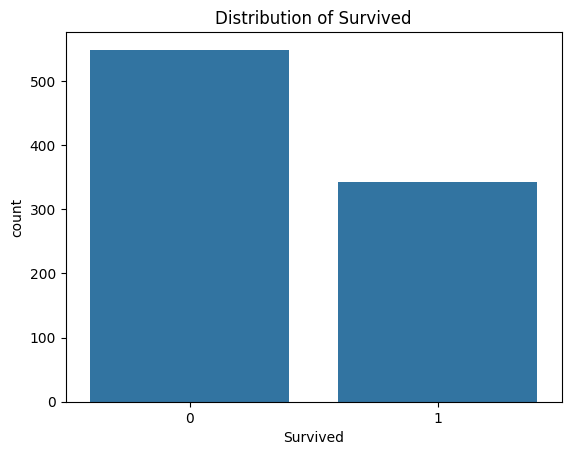

In [5]:
# Target distribution
sns.countplot(x='Survived', data=df)
plt.title('Distribution of Survived')
plt.show()

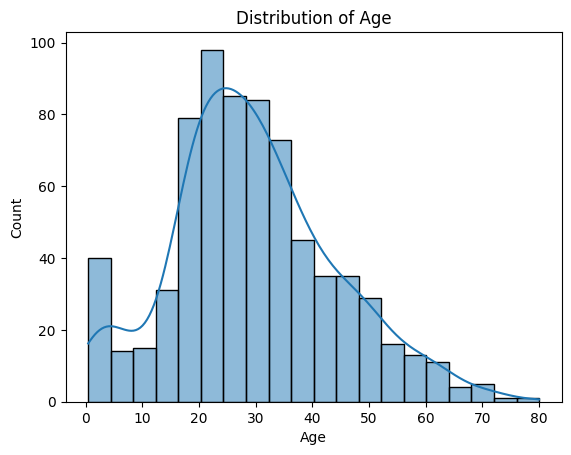

In [6]:
# Age distribution
sns.histplot(df['Age'].dropna(), kde=True)
plt.title('Distribution of Age')
plt.show()

## 3. Data Preprocessing (Manual)

In [7]:
# Handling missing values
df['Age'] = df['Age'].fillna(df['Age'].mean())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Drop Cabin (too many missing), Name, Ticket, PassengerId (high cardinality/irrelevant)
df = df.drop(columns=['Cabin', 'Name', 'Ticket', 'PassengerId'])

In [8]:
# Encoding categorical features
df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Splitting Features and Target
X = df.drop('Survived', axis=1)
y = df['Survived']

# Scaling numerical features
scaler = StandardScaler()
X[['Age', 'Fare']] = scaler.fit_transform(X[['Age', 'Fare']])

print('Data shape:', X.shape)
X.head()

Data shape: (891, 8)


,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,3,-0.592481,1,0,-0.502445,True,False,True
1,1,0.638789,1,0,0.786845,False,False,False
2,3,-0.284663,0,0,-0.488854,False,False,True
3,1,0.407926,1,0,0.420730,False,False,True
4,3,0.407926,0,0,-0.486337,True,False,True


In [10]:
# Saving processed data
output_path = 'titanic_preprocessing/train_processed.csv'
processed_df = pd.concat([y, X], axis=1)
processed_df.to_csv(output_path, index=False)
print(f'Processed data saved to {output_path}')

Processed data saved to titanic_preprocessing/train_processed.csv
